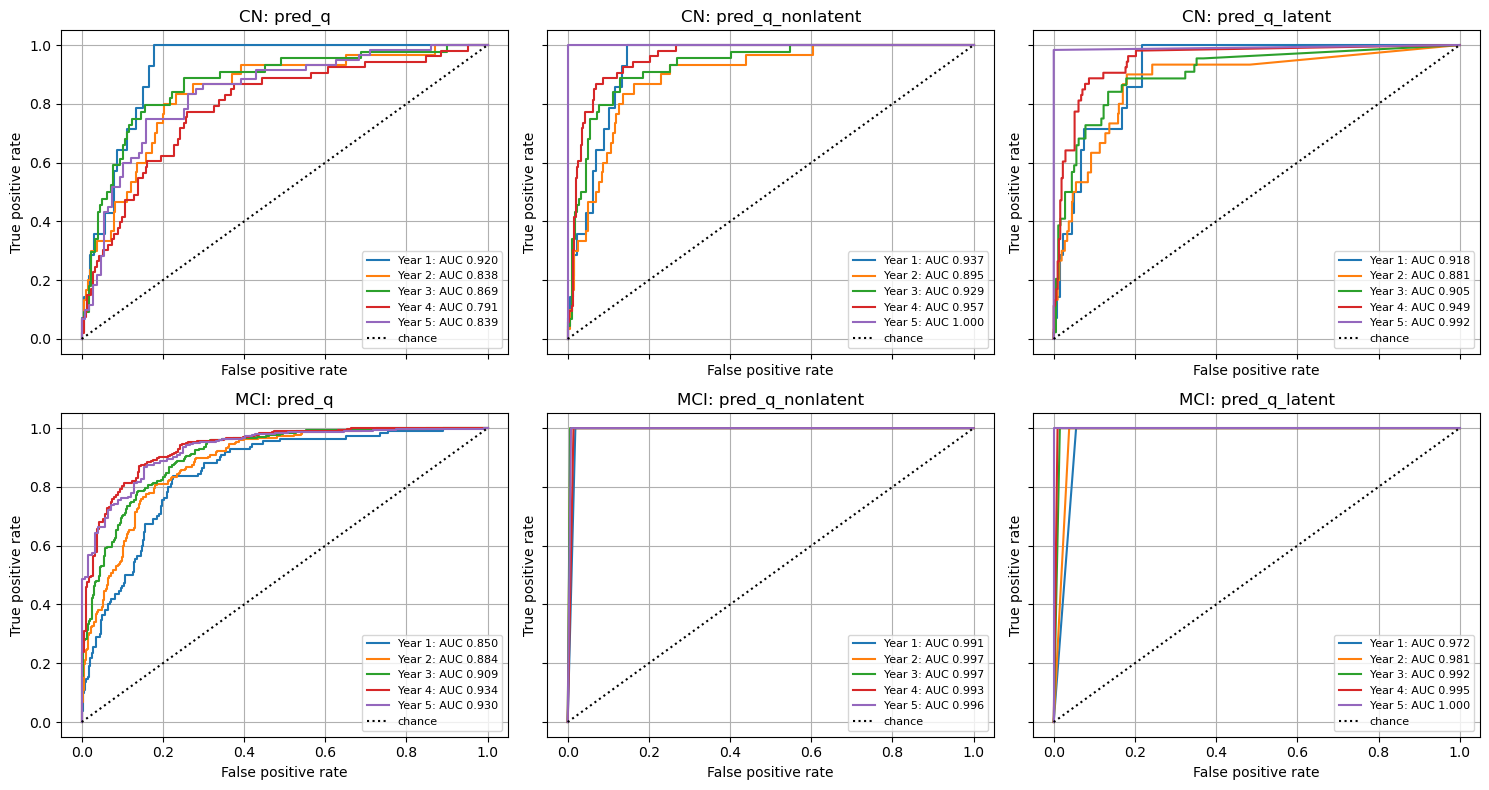

,baseline,year,prediction,positive_true_q,ROCAUC,n,n_positive,n_negative
0,CN,1,pred_q,0.5,0.919749,435,14,421
1,CN,2,pred_q,0.5,0.838291,541,30,511
2,CN,3,pred_q,0.5,0.869223,223,44,179
3,CN,4,pred_q,0.5,0.791057,364,53,311
4,CN,5,pred_q,0.5,0.838629,167,60,107
5,CN,1,pred_q_nonlatent,0.5,0.936715,435,14,421
6,CN,2,pred_q_nonlatent,0.5,0.895303,541,30,511
7,CN,3,pred_q_nonlatent,0.5,0.929152,223,44,179
8,CN,4,pred_q_nonlatent,0.5,0.956804,364,53,311
9,CN,5,pred_q_nonlatent,0.5,1.000000,167,60,107


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

df = pd.read_csv("post_optimisation_q.csv")

pred_cols = ["pred_q", "pred_q_nonlatent", "pred_q_latent"]
years = [1, 2, 3, 4, 5]

# Match MLBasedAD-style annual grouping.
# If FollowupYear already exists, use it; otherwise derive it from delta_t in months.
if "FollowupYear" not in df.columns:
    df["FollowupYear"] = np.rint(df["delta_t"].astype(float) / 12.0).astype(int)

tasks = {
    "CN": {
        "mask": df["BaselineDX"] == 0,
        "positive_q": 0.5,  # CN baseline: MCI vs CN/rest
    },
    "MCI": {
        "mask": df["BaselineDX"] == 1,
        "positive_q": 1.0,  # MCI baseline: AD vs MCI/rest
    },
}

auc_rows = []

fig, axes = plt.subplots(
    nrows=len(tasks),
    ncols=len(pred_cols),
    figsize=(5 * len(pred_cols), 4 * len(tasks)),
    sharex=True,
    sharey=True,
)

for row_i, (task_name, task) in enumerate(tasks.items()):
    for col_i, pred_col in enumerate(pred_cols):
        ax = axes[row_i, col_i]

        for year in years:
            sub = df.loc[
                task["mask"] & (df["FollowupYear"] == year),
                ["true_q", pred_col],
            ].dropna()

            y_true = (sub["true_q"].astype(float) == task["positive_q"]).astype(int)
            y_score = sub[pred_col].astype(float)

            if y_true.nunique() < 2:
                auc_rows.append({
                    "baseline": task_name,
                    "year": year,
                    "prediction": pred_col,
                    "positive_true_q": task["positive_q"],
                    "ROCAUC": np.nan,
                    "n": len(y_true),
                    "n_positive": int(y_true.sum()),
                    "n_negative": int((1 - y_true).sum()),
                })
                continue

            auc = roc_auc_score(y_true, y_score)
            fpr, tpr, thresholds = roc_curve(y_true, y_score)

            auc_rows.append({
                "baseline": task_name,
                "year": year,
                "prediction": pred_col,
                "positive_true_q": task["positive_q"],
                "ROCAUC": auc,
                "n": len(y_true),
                "n_positive": int(y_true.sum()),
                "n_negative": int((1 - y_true).sum()),
            })

            ax.plot(fpr, tpr, label=f"Year {year}: AUC {auc:.3f}")

        ax.plot([0, 1], [0, 1], ":k", label="chance")
        ax.set_title(f"{task_name}: {pred_col}")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.grid(True)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

auc_df = pd.DataFrame(auc_rows)
auc_df
